<a href="https://colab.research.google.com/github/ParthGadekar0631/AAI-595_Homeworks/blob/main/Homework_2_Parth_Gadekar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Name: Parth Yashwant Gadekar
###CWID: 20029972
###Course: AAI 595-A Applied Machine Learning

##Programming Problem:

Write a program to find the coefficients for a linear regression model for the dataset provided
(data2.txt). Assume a linear model: y = w0 + w1*x.

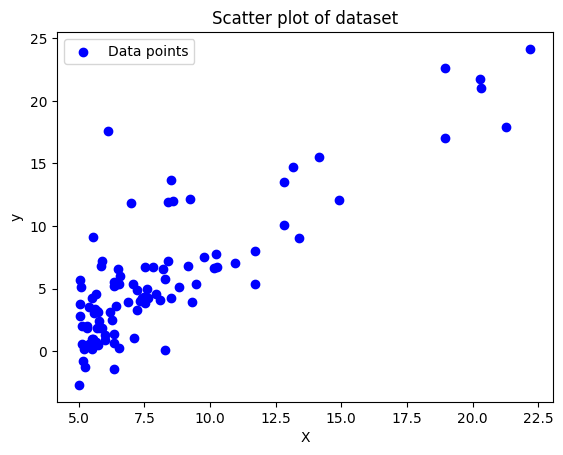

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------------------------------
# **Q1: Plot the Dataset**
# ---------------------------------------------------------------------------------

# Load dataset from file
data = np.loadtxt('data2.txt', delimiter=',')
X = data[:, 0].reshape(-1, 1)
y = data[:, 1]

# Display dataset scatter plot
plt.scatter(X, y, color='blue', label='Data points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter plot of dataset')
plt.legend()
plt.show()

Normal Equation Coefficients: [-3.89578088  1.19303364]


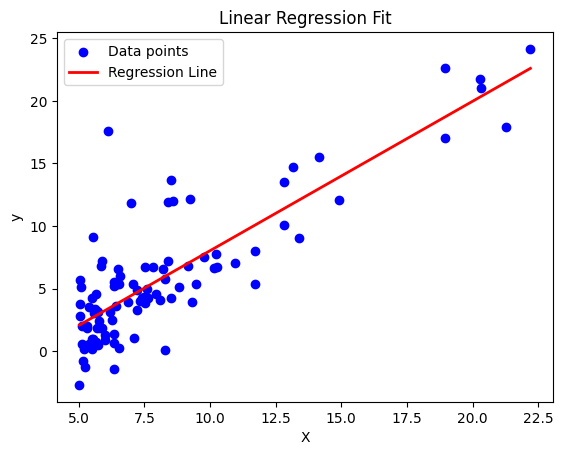

In [ ]:
# ---------------------------------------------------------------------------------
# **Q2: Compute Coefficients Using Normal Equation**
# ---------------------------------------------------------------------------------

# Add intercept term to X
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Compute theta using Normal Equation
theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print(f"Normal Equation Coefficients: {theta_normal}")

# Plot dataset with regression line
plt.scatter(X, y, color='blue', label='Data points')

# Compute predictions using the normal equation
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_b = np.c_[np.ones((X_plot.shape[0], 1)), X_plot]
y_pred = X_plot_b @ theta_normal  # Predicted values

plt.plot(X_plot, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

In [ ]:
# ---------------------------------------------------------------------------------
# **Q3(a): Split Data into Training (80%) and Testing (20%)**
# ---------------------------------------------------------------------------------

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)
print(f"Training Samples: {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")

# ---------------------------------------------------------------------------------
# **Q3(b): Implementing Batch and Stochastic Gradient Descent**
# ---------------------------------------------------------------------------------

# Cost function
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X @ theta
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

# Batch Gradient Descent
def batch_gradient_descent(X, y, learning_rate=0.01, threshold=1e-6, max_iters=1000):
    m, n = X.shape
    theta = np.zeros(n)
    cost_train_history = []
    cost_test_history = []

    for _ in range(max_iters):
        gradient = (1 / m) * X.T @ (X @ theta - y)
        theta -= learning_rate * gradient

        # Record training & testing cost
        cost_train = compute_cost(X_train, y_train, theta)
        cost_test = compute_cost(X_test, y_test, theta)
        cost_train_history.append(cost_train)
        cost_test_history.append(cost_test)

        if cost_train < threshold:
            break

    return theta, cost_train_history, cost_test_history

# Stochastic Gradient Descent
def stochastic_gradient_descent(X, y, learning_rate=0.01, threshold=1e-6, max_iters=100):
    m, n = X.shape
    theta = np.zeros(n)
    cost_train_history = []
    cost_test_history = []

    for _ in range(max_iters):
        for i in range(m):
            rand_idx = np.random.randint(m)
            xi = X[rand_idx:rand_idx+1]
            yi = y[rand_idx:rand_idx+1]
            gradient = xi.T @ (xi @ theta - yi)
            theta -= learning_rate * gradient

        # Record training & testing cost
        cost_train = compute_cost(X_train, y_train, theta)
        cost_test = compute_cost(X_test, y_test, theta)
        cost_train_history.append(cost_train)
        cost_test_history.append(cost_test)

        if cost_train < threshold:
            break

    return theta, cost_train_history, cost_test_history


Training Samples: 77, Testing Samples: 20


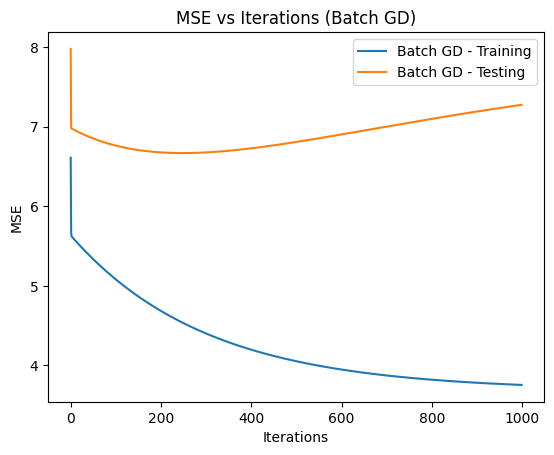

In [ ]:
# ---------------------------------------------------------------------------------
# **Q3(b) - Plot MSE vs Iterations for Batch Gradient Descent**
# ---------------------------------------------------------------------------------

theta_batch, cost_train_batch, cost_test_batch = batch_gradient_descent(X_train, y_train)

plt.plot(cost_train_batch, label='Batch GD - Training')
plt.plot(cost_test_batch, label='Batch GD - Testing')
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.title('MSE vs Iterations (Batch GD)')
plt.legend()
plt.show()

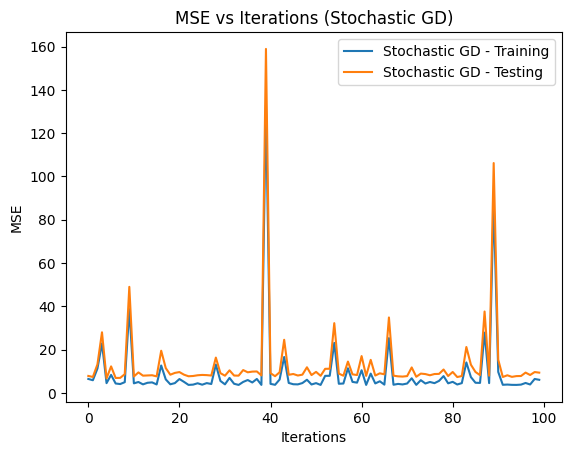

In [ ]:
# ---------------------------------------------------------------------------------
# **Q3(b) - Plot MSE vs Iterations for Stochastic Gradient Descent**
# ---------------------------------------------------------------------------------

theta_stoch, cost_train_stoch, cost_test_stoch = stochastic_gradient_descent(X_train, y_train)

plt.plot(cost_train_stoch, label='Stochastic GD - Training')
plt.plot(cost_test_stoch, label='Stochastic GD - Testing')
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.title('MSE vs Iterations (Stochastic GD)')
plt.legend()
plt.show()

### **Batch vs. Stochastic Gradient Descent**
- **Accuracy**: Batch GD gives more stable and lower test MSE, while Stochastic GD is noisier but can still find a good solution.
- **Speed**: Stochastic GD updates parameters faster, but its convergence path fluctuates more.
- **Best Learning Rate**: A balanced learning rate avoids instability (too high) or slow convergence (too low).
- **Choosing Between Them**:
  - **Batch GD** → More accurate, better for small datasets.
  - **Stochastic GD** → Faster, better for large datasets.


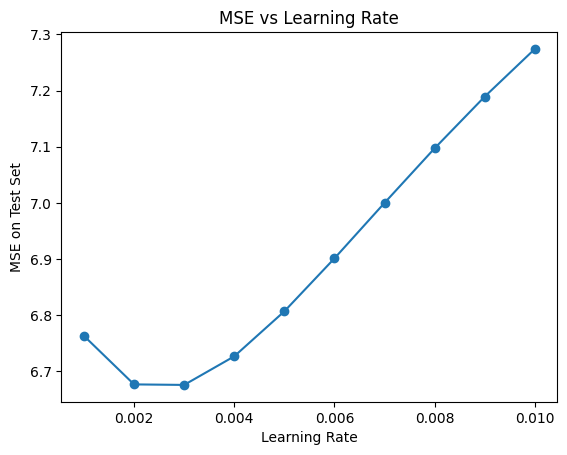

Best learning rate: 0.003


In [ ]:
# ---------------------------------------------------------------------------------
# **Q3(c): Determine the Best Learning Rate**
# ---------------------------------------------------------------------------------

learning_rates = np.arange(0.001, 0.011, 0.001)
mse_values = []

for lr in learning_rates:
    theta_batch, _, _ = batch_gradient_descent(X_train, y_train, learning_rate=lr)
    mse_values.append(compute_cost(X_test, y_test, theta_batch))

# Find and print the best learning rate
best_lr = learning_rates[np.argmin(mse_values)]

# Plot MSE vs. Learning Rate
plt.plot(learning_rates, mse_values, marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('MSE on Test Set')
plt.title('MSE vs Learning Rate')
plt.show()
print(f'Best learning rate: {best_lr}')